# 01 — Data and data-generating processes
Inspect the controlled DGPs and the four-asset return panel. This notebook performs no model fitting.

In [1]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
from innovcal.data import simulate_multivariate_series

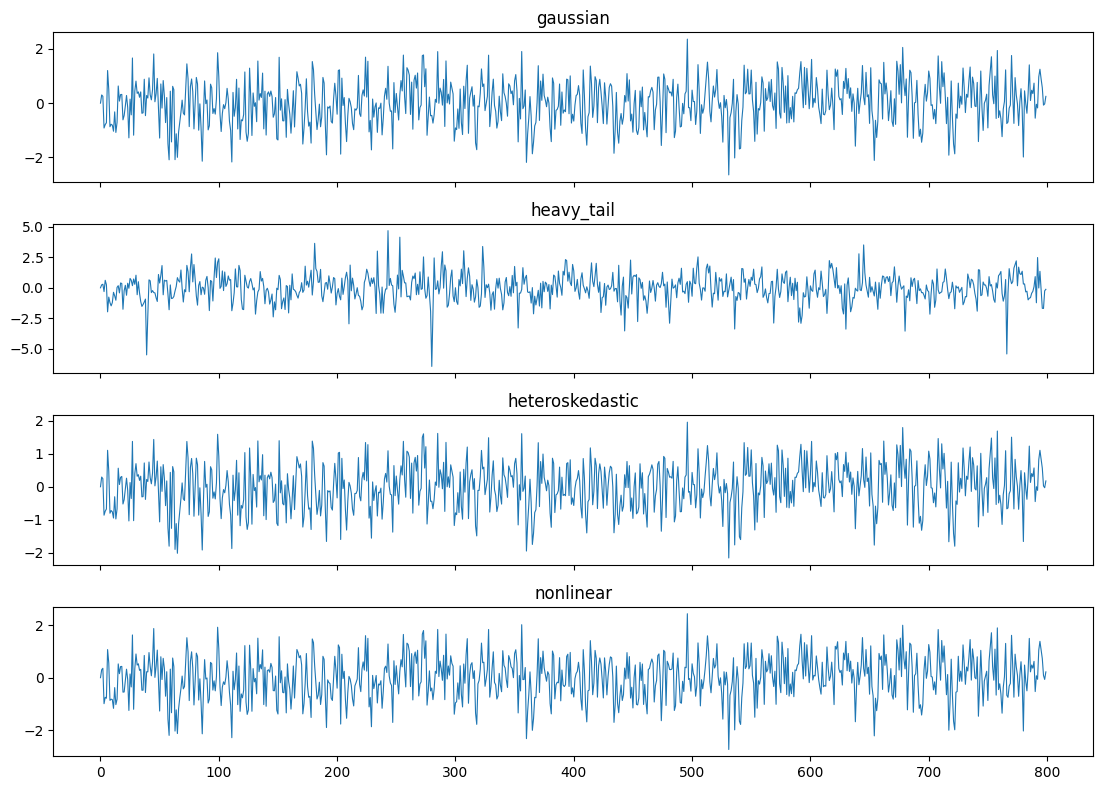

In [2]:
regimes = ['gaussian', 'heavy_tail', 'heteroskedastic', 'nonlinear']
fig, axes = plt.subplots(len(regimes), 1, figsize=(11, 8), sharex=True)
for axis, regime in zip(axes, regimes):
    series = simulate_multivariate_series(800, regime=regime, seed=123)
    axis.plot(series[:, 0], linewidth=0.8)
    axis.set_title(regime)
plt.tight_layout()

,count,mean,std,min,25%,50%,75%,max
AAPL,4779.0,0.000980,0.019793,-0.197470,-0.007833,0.001094,0.011151,0.142617
JPM,4779.0,0.000499,0.023427,-0.232278,-0.008328,0.000540,0.009582,0.223917
XOM,4779.0,0.000240,0.016958,-0.150271,-0.007653,0.000246,0.008483,0.158631
WMT,4779.0,0.000490,0.013044,-0.120765,-0.005550,0.000659,0.006635,0.110723


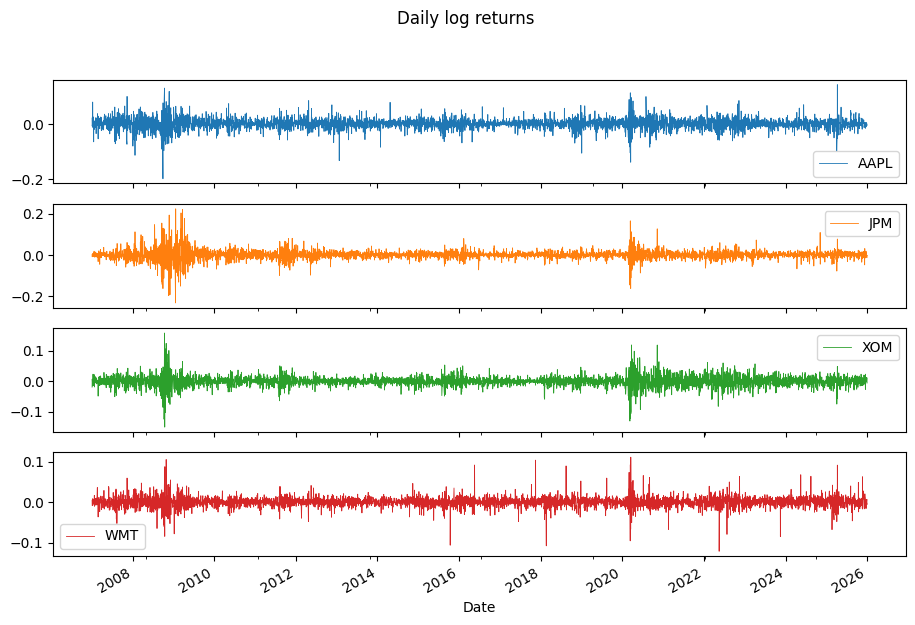

In [3]:
returns_path = ROOT / 'data' / 'processed' / 'financial_returns.csv'
if returns_path.exists():
    returns = pd.read_csv(returns_path, index_col=0, parse_dates=True)
    display(returns.describe().T)
    returns.plot(subplots=True, figsize=(11, 7), linewidth=0.6, title='Daily log returns')
else:
    print('No local financial panel found. Run notebook 06 to download it.')